# Rotazione arbitraria $U_R\in SU(2)$ nel paradigma MBQC
su cluster lineare a cinque qubit

## References
- _A One-Way Quantum Computer_, Raussendorf R. and Briegel H.J., Phys. Rev. Lett., 86, 22, 5188-5191, 2001, American Physical Society, [DOI](https://link.aps.org/doi/10.1103/PhysRevLett.86.5188)
- *Measurement-based quantum computation on cluster states*, Raussendorf R. , Browne D. E. and Briegel H. J., **Physical Review A**, 68, 022312, 2003, [DOI](https://link.aps.org/doi/10.1103/PhysRevA.68.022312).

## Setup dell'ambiente

Le celle seguenti installano le dipendenze e impostano come directory di lavoro
la cartella che contiene il notebook. Dopo l'installazione delle dipendenze può
essere necessario riavviare il kernel.

Su Google Colab, il setup scarica il repository (branch `main`) e seleziona la cartella dell’esempio prima di installare le dipendenze. Se richiesto, riavvia la sessione e riesegui le celle. Il clone viene riutilizzato nella stessa sessione; per scaricare aggiornamenti da GitHub, avvia una nuova sessione Colab.


In [ ]:
from pathlib import Path
import os
import subprocess

try:
    import google.colab
except ImportError:
    IN_COLAB = False
else:
    IN_COLAB = True

if IN_COLAB:
    repository = Path("/content/mbqc-codes")
    if not repository.exists():
        subprocess.run([
            "git", "clone", "--depth", "1", "--branch", "main",
            "https://github.com/AlbertoMiserendino/mbqc-codes.git",
            str(repository),
        ], check=True)
    os.chdir(repository / "02-mbqc-rotation")

%pip install -r "../requirements.txt" -q
# If prompted, restart the runtime/kernel and run the cells again.


In [2]:
from pathlib import Path
import os
import ipynbname

# Automated runs already start in the notebook directory.
if not Path("mbqc-rotation.qasm").is_file():
    os.chdir(ipynbname.path().parent)


/home/alberto/qc/02-mbqc-rotation


## Rotazione arbitraria su un cluster lineare

Consideriamo il cluster lineare di 5 qubit

$$
q_0-q_1-q_2-q_3-q_4,
$$

dove $q_0$ contiene lo stato di ingresso e $q_4$ è il qubit di uscita. 

Per rendere la verifica finale non banale e senza perdità di generalità prepariamo lo stato iniziale in

$$
|\psi_{\mathrm{in}}\rangle
=
R_z(\phi)R_y(\theta)|0\rangle.
$$

L'operazione da realizzare è una rotazione arbitraria di $SU(2)$. Scriviamo questa nella
decomposizione di Eulero $XZX$ come

$$
U_R(\xi,\eta,\zeta)
=
R_x(\zeta)R_z(\eta)R_x(\xi),
$$

con

$$
R_x(\alpha)=e^{-i\alpha X/2},
\qquad
R_z(\alpha)=e^{-i\alpha Z/2}.
$$

I qubit $q_1,\ldots,q_4$ vengono inizializzati in $|+\rangle$ e i collegamenti del cluster sono realizzati tramite porte $CZ$.

$$
\left|\psi_{\mathrm{in}}\right\rangle_5
=
\left|\psi_{\mathrm{in}}\right\rangle_0
\otimes
\left(
\bigotimes_{i=1}^{4} |+\rangle_i
\right)\qquad\overset{S^{(\mathcal C_5)}}{\longmapsto}\qquad S^{(\mathcal C_5)} \left|\psi_{\mathrm{in}}\right\rangle_5
$$

La misura dei primi quattro qubit teleporta lo stato verso $q_4$ e, contemporaneamente, implementa $U_R$.

## Basi di misura adattive

I qubit $j$-esimi sono misurati in basi equatorili opportune:

$$
\mathcal B_j(\alpha_j)
=
\left\{
\frac{|0\rangle+e^{i\alpha_j}|1\rangle}{\sqrt2},
\frac{|0\rangle-e^{i\alpha_j}|1\rangle}{\sqrt2}
\right\}.
$$

Con questa definizione, una misura in $\mathcal B_j(\alpha_j)$ può essere
realizzata applicando prima $R_z(-\alpha_j)$, poi $H$, e infine misurando
nella base computazionale (infatti $R_z(-\alpha)$ elimina la fase relativa $e^{i\alpha}$, trasformando la base $\{|\!+_\alpha\rangle,|\!-_\alpha\rangle\}$ nella base $X$; poi $H$ trasforma $X$ in $Z$).

Per l'implementazione si adotta la convenzione esplicita della derivazione
dettagliata di Raussendorf, Browne e Briegel (2003):

$$
\begin{aligned}
\alpha_1 &= 0,\\
\alpha_2 &= -(-1)^{s_1}\xi
          =(-1)^{s_1+1}\xi,\\
\alpha_3 &= -(-1)^{s_2}\eta
          =(-1)^{s_2+1}\eta,\\
\alpha_4 &= -(-1)^{s_1+s_3}\zeta
          =(-1)^{s_1+s_3+1}\zeta.
\end{aligned}
$$

Gli esiti $s_j\in\{0,1\}$ determinano quindi il segno delle basi successive:
questa dipendenza classica è il **feed-forward** caratteristico dell'MBQC.

> **Nota sui segni.** L'estratto del lavoro del 2001 riporta la procedura in una
> forma abbreviata. Nel circuito OpenQASM sottostante i segni sono scritti in
> modo coerente con la definizione esplicita di $\mathcal B(\alpha)$, con la
> convenzione $R_z(\alpha)=e^{-i\alpha Z/2}$, e con la procedura
> dettagliata del 2003.

## Byproduct di Pauli correction

Dopo le quattro misure, prima della correzione, il qubit di uscita è *ruotato* come

$$
|\psi'_{\mathrm{out}}\rangle
=
\underbrace{X^{s_2\oplus s_4}Z^{s_1\oplus s_3}}_{\equiv U_\Sigma}\;
%
U_R(\xi,\eta,\zeta)\;
%
|\psi_{\mathrm{in}}\rangle.
$$

Il fattore $U_\Sigma$ è un *Pauli byproduct*: non modifica l'operazione logica desiderata, ma dipende dagli esiti casuali delle misure. Lo possiamo rimuovere al termine del calcolo applicando l'inversa

$$
U_\Sigma^{-1}
=
Z^{s_1\oplus s_3}X^{s_2\oplus s_4}.
$$

## Circuito OpenQASM

Il file OpenQASM contiene la preparazione dello stato di ingresso, la creazione
del cluster, le quattro misure adattive e le correzioni finali sul qubit
$q_4$.

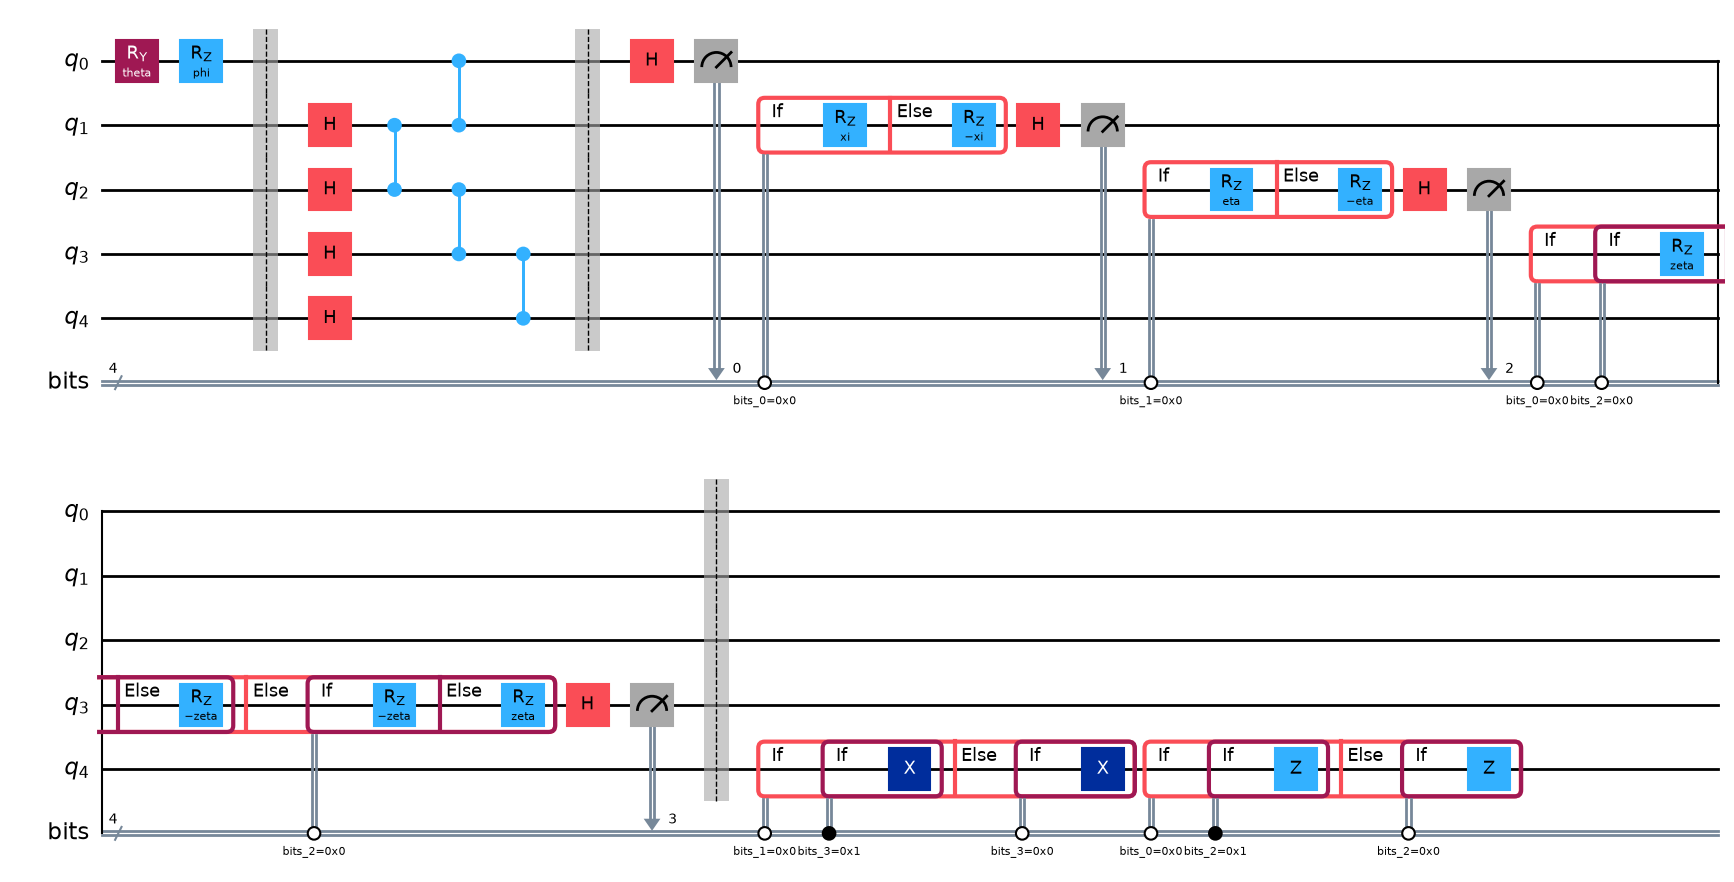

In [3]:
from qiskit import qasm3

# Carica il circuito dinamico MBQC descritto in OpenQASM 3.
qc = qasm3.load("./mbqc-rotation.qasm")

# Visualizza il circuito completo; fold limita la larghezza del disegno.
qc.draw("mpl", fold=25)

## Parametri numerici

Il circuito possiede cinque parametri:

- $\theta,\phi$ preparano lo stato arbitrario di ingresso;
- $\xi,\eta,\zeta$ definiscono la rotazione $U_R$.

Si scelgono valori non speciali, in modo che la verifica coinvolga tutte le
componenti del vettore di Bloch.

In [4]:
# Mostra i parametri simbolici importati dal file OpenQASM.
print("Numero di parametri:", qc.num_parameters)
print("Parametri:", qc.parameters)

Numero di parametri: 5
Parametri: ParameterView([Parameter(eta), Parameter(phi), Parameter(theta), Parameter(xi), Parameter(zeta)])


In [5]:
import numpy as np

# Dizionario nome -> oggetto Parameter, utile per il binding per nome.
params = {p.name: p for p in qc.parameters}

# Stato di ingresso |psi_in> = Rz(phi) Ry(theta) |0>.
theta_value = np.pi / 3
phi_value = np.pi / 5

# Angoli di Eulero della rotazione U_R = Rx(zeta) Rz(eta) Rx(xi).
xi_value = np.pi / 4
eta_value = -np.pi / 6
zeta_value = np.pi / 3

# Sostituisce tutti i parametri simbolici con valori numerici.
qc_bound = qc.assign_parameters({
    params["theta"]: theta_value,
    params["phi"]: phi_value,
    params["xi"]: xi_value,
    params["eta"]: eta_value,
    params["zeta"]: zeta_value,
})

print("Parametri residui:", qc_bound.parameters)

Parametri residui: ParameterView([])


## Verifica del qubit di uscita

Dopo il feed-forward e le correzioni, lo stato logico si trova su $q_4$.
Possiamo il vettore di Bloch stimando 
$$
\langle X\rangle,\qquad
\langle Y\rangle,\qquad
\langle Z\rangle\;.
$$
Avremo quindi che $\vec{r} = \left(\langle X\rangle,\langle Y\rangle,\langle Z\rangle\right)$.

Per non sovrascrivere i quattro bit classici $s_1,\ldots,s_4$, ciascuna
copia del circuito riceve un nuovo registro classico `out` dedicato alla misura
finale.

Il cambio di base prima della misura computazionale è

$$
M_X=M_ZH,
\qquad
M_Y=M_ZHS^\dagger,
\qquad
M_Z=M_Z.
$$

In [6]:
from qiskit import ClassicalRegister

# il qubit di uscita è q[4].
OUTPUT_QUBIT = 4

def circuit_for_pauli_measurement(circuit, basis):
    """Restituisce una copia del circuito con q[4] misurato in X, Y o Z."""
    measured = circuit.copy()

    # Registro dedicato alla sola misura di output (1 solo bit).
    out = ClassicalRegister(1, f"out_{basis.lower()}")
    measured.add_register(out)

    # Cambio di base prima della misura Z.
    if basis == "X":
        measured.h(OUTPUT_QUBIT)
    elif basis == "Y":
        measured.sdg(OUTPUT_QUBIT)
        measured.h(OUTPUT_QUBIT)
    elif basis != "Z":
        raise ValueError("basis deve essere 'X', 'Y' oppure 'Z'")

    measured.measure(OUTPUT_QUBIT, out[0])

    # Ricaviamo l'indice effettivo del bit, senza assumere a priori che sia 4.
    out_index = measured.find_bit(out[0]).index

    return measured, out_index


qc_x, out_x = circuit_for_pauli_measurement(qc_bound, "X")
qc_y, out_y = circuit_for_pauli_measurement(qc_bound, "Y")
qc_z, out_z = circuit_for_pauli_measurement(qc_bound, "Z")

In [7]:
out_x, out_y, out_z

(4, 4, 4)

## Simulazione

Il circuito contiene controllo classico dinamico perché le basi di misura
dipendono dagli esiti precedenti. Le tre copie vengono quindi traspilate per
`AerSimulator` ed eseguite con un numero elevato di *shots*.

In [8]:
from qiskit import transpile
from qiskit_aer import AerSimulator

sim = AerSimulator()
shots = 10_000

# La traspilazione prepara i circuiti dinamici per il backend Aer.
tqc_x = transpile(qc_x, sim)
tqc_y = transpile(qc_y, sim)
tqc_z = transpile(qc_z, sim)

result_x = sim.run(tqc_x, shots=shots).result()
result_y = sim.run(tqc_y, shots=shots).result()
result_z = sim.run(tqc_z, shots=shots).result()

counts_x = result_x.get_counts()
counts_y = result_y.get_counts()
counts_z = result_z.get_counts()

In [9]:
# primi 10 conteggi
from pprint import pprint
pprint(list(counts_x.items())[:10])

[('1 0101', 129),
 ('1 1111', 122),
 ('1 1011', 124),
 ('0 1111', 491),
 ('0 0101', 520),
 ('0 1001', 504),
 ('1 1010', 106),
 ('1 0001', 108),
 ('0 1110', 508),
 ('0 0100', 531)]


```
('1 1110', 122),
 │   │      └── occorrenza   
 │   └── risultati delle misure precedenti s₁,...,s₄
 └────── risultato finale out_x
```
$2^5=32$ configurazioni

In [10]:
len(counts_x.items())

32

## Marginalizzazione sul solo bit di uscita

I conteggi completi contengono anche $s_1,\ldots,s_4$ (registro `bits`), che servono al feed-forward ma non alla tomografia finale. Marginalizzando rispetto a questi bit ed estraendo il solo registro `out`, si ottengono direttamente le statistiche della misura finale sul qubit $q_4$.

X: {'1': 1902, '0': 8098}
Y: {'0': 1030, '1': 8970}
Z: {'1': 4727, '0': 5273}


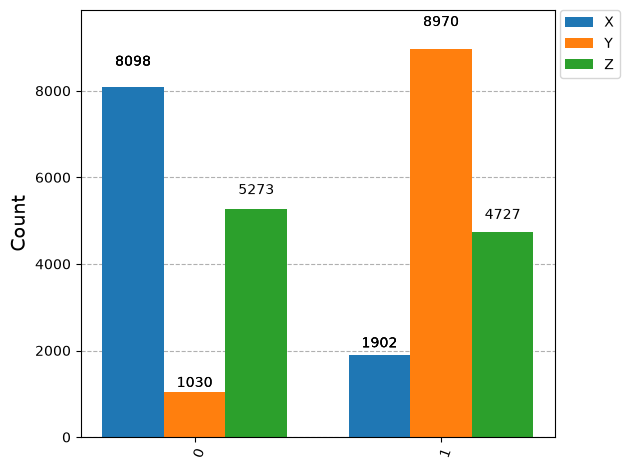

In [11]:
from qiskit.result import marginal_counts
from qiskit.visualization import plot_histogram
from IPython.display import display

# Mantiene esclusivamente il bit associato alla misura finale di q[4].
mx = marginal_counts(counts_x, indices=[out_x])
my = marginal_counts(counts_y, indices=[out_y])
mz = marginal_counts(counts_z, indices=[out_z])

print("X:", mx)
print("Y:", my)
print("Z:", mz)

# Mostra soltanto le distribuzioni marginali del qubit di uscita.
display(plot_histogram(
    [mx, my, mz],
    legend=["X", "Y", "Z"]
))

## Valori di aspettazione

Per una misura di Pauli $P\in\{X,Y,Z\}$, con risultati $0$ e $1$,

$$
\langle P\rangle
=
\frac{N_0-N_1}{N_0+N_1}.
$$

Le tre quantità formano il vettore di Bloch ricostruito

$$
\mathbf r_{\mathrm{meas}}
=
\left(
\langle X\rangle,
\langle Y\rangle,
\langle Z\rangle
\right).
$$

In [12]:
def expectation(counts):
    """Stima <P> dai conteggi binari di una misura di Pauli."""

    n0 = counts.get("0", 0)
    n1 = counts.get("1", 0)

    return (n0 - n1) / (n0 + n1)


# Componenti sperimentali del vettore di Bloch di q[4].
x_meas = expectation(mx)
y_meas = expectation(my)
z_meas = expectation(mz)

print("<X> misurato =", x_meas)
print("<Y> misurato =", y_meas)
print("<Z> misurato =", z_meas)

<X> misurato = 0.6196
<Y> misurato = -0.794
<Z> misurato = 0.0546


## Stato teorico di riferimento

La verifica teorica viene costruita indipendentemente dal circuito MBQC.
Su un singolo qubit prepariamo lo stesso stato di ingresso e applichiamo
direttamente

$$
U_R(\xi,\eta,\zeta)
=
R_x(\zeta)R_z(\eta)R_x(\xi).
$$

Il target è quindi

$$
|\psi_{\mathrm{target}}\rangle
=
R_x(\zeta)R_z(\eta)R_x(\xi)
R_z(\phi)R_y(\theta)|0\rangle.
$$

Il suo vettore di Bloch deve coincidere, entro l'errore statistico degli
*shots*, con quello ottenuto dal circuito MBQC.

In [13]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Pauli, Statevector

# Circuito di riferimento nel modello standard a porte.
reference = QuantumCircuit(1)

# Prepara |psi_in>.
reference.ry(theta_value, 0)
reference.rz(phi_value, 0)

# Applica U_R = Rx(zeta) Rz(eta) Rx(xi).
# L'ordine temporale delle chiamate è xi -> eta -> zeta.
reference.rx(xi_value, 0)
reference.rz(eta_value, 0)
reference.rx(zeta_value, 0)

psi_theory = Statevector.from_instruction(reference)

# Valori teorici delle tre osservabili di Pauli.
x_theory = float(np.real(psi_theory.expectation_value(Pauli("X"))))
y_theory = float(np.real(psi_theory.expectation_value(Pauli("Y"))))
z_theory = float(np.real(psi_theory.expectation_value(Pauli("Z"))))

print("<X> teorico =", x_theory)
print("<Y> teorico =", y_theory)
print("<Z> teorico =", z_theory)

<X> teorico = 0.6099577937907781
<Y> teorico = -0.7902967457439002
<Z> teorico = 0.058159637726587554


## Confronto numerico

Gli scarti osservati devono essere compatibili con le fluttuazioni statistiche dovute al numero finito di *shots*.

Per una probabilità teorica $p$, la frequenza stimata su $N$ esecuzioni ha deviazione standard

$$
\sigma_{\hat p}=\sqrt{\frac{p(1-p)}{N}}.
$$

Con $N=10^4$ *shots*, l'incertezza è massima per $p=0.5$:

$$
\sigma_{\max}
=
\sqrt{\frac{0.25}{10^4}}
=
5\times10^{-3}.
$$

Pertanto, scarti dell'ordine di $10^{-2}$ sono compatibili con le normali fluttuazioni statistiche associate al campionamento finito. Un accordo entro pochi $10^{-2}$, o migliore, è quindi ragionevole per $10^4$ *shots* per base.



In [14]:
# Confronto componente per componente.
print("       misurato          teorico             |errore|")
print(f"<X>   {x_meas: .6f}     {x_theory: .6f}     {abs(x_meas - x_theory):.6f}")
print(f"<Y>   {y_meas: .6f}     {y_theory: .6f}     {abs(y_meas - y_theory):.6f}")
print(f"<Z>   {z_meas: .6f}     {z_theory: .6f}     {abs(z_meas - z_theory):.6f}")

       misurato          teorico             |errore|
<X>    0.619600      0.609958     0.009642
<Y>   -0.794000     -0.790297     0.003703
<Z>    0.054600      0.058160     0.003560


## Fedeltà

Per un target puro con vettore di Bloch $\mathbf r_{\mathrm{th}}$ e uno stato
ricostruito con vettore $\mathbf r_{\mathrm{meas}}$,

$$
F
=
\frac{1+\mathbf r_{\mathrm{th}}\cdot\mathbf r_{\mathrm{meas}}}{2}.
$$

Per effetto delle fluttuazioni statistiche la norma del vettore ricostruito può
risultare di poco superiore a $1$; in quel caso viene riportata sulla sfera
di Bloch prima del calcolo.

In [15]:
# Vettore di Bloch misurato.
r_meas = np.array([x_meas, y_meas, z_meas], dtype=float)

# Piccola correzione numerica solo se la stima statistica cade fuori dalla sfera.
norm = np.linalg.norm(r_meas)
if norm > 1:
    r_meas = r_meas / norm

# Vettore di Bloch del target puro.
r_theory = np.array([x_theory, y_theory, z_theory], dtype=float)

# Fedeltà tra il target puro e lo stato ricostruito.
fidelity = (1 + np.dot(r_theory, r_meas)) / 2

print("Fidelity =", fidelity)

Fidelity = 0.999988847948523


La fedeltà unitaria conferma che lo stato ottenuto coincide con quello teoricamente atteso

Se le basi adattive e le correzioni sono implementate correttamente, il qubit
$q_4$ contiene

$$
\boxed{
|\psi_{\mathrm{out}}\rangle
=
U_R(\xi,\eta,\zeta)|\psi_{\mathrm{in}}\rangle
}.
$$

La rotazione nel circuito MBQC: emerge dalla sequenza di misure
adattive sul cluster, mentre l'informazione quantistica viene teletrasportata
da $q_0$ a $q_4$.

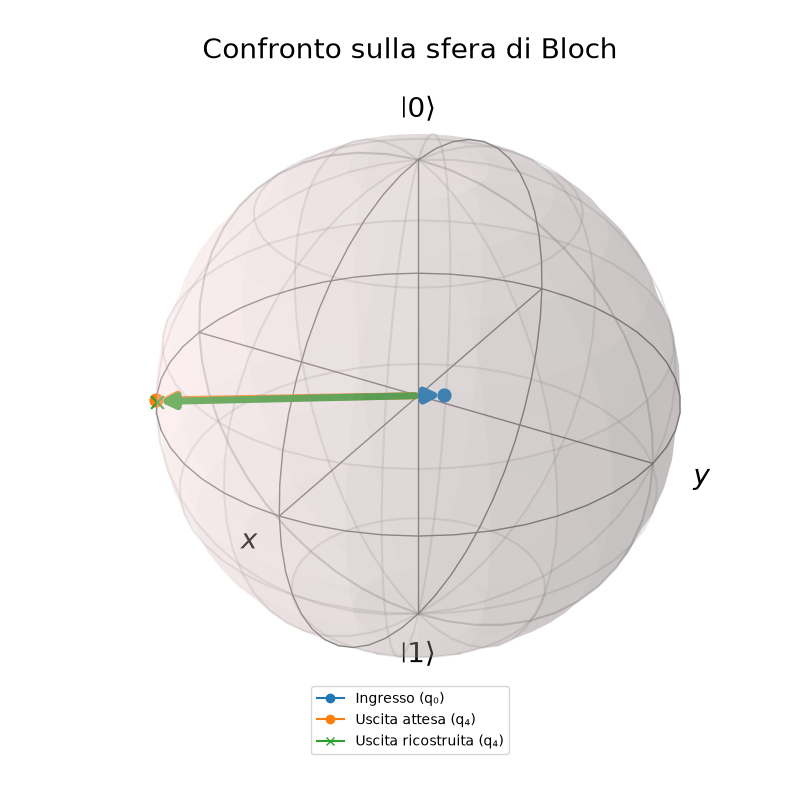

In [16]:
# Dopo la prima installazione di ipympl, riavvia il kernel.
# Trascina per ruotare la sfera; usa la barra strumenti per lo zoom.
try:
    from google.colab import output
except ImportError:
    pass
else:
    output.enable_custom_widget_manager()

%matplotlib widget

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from qiskit.visualization.bloch import Bloch


class BlochComparison:
    """Confronta ingresso e uscite su una sfera di Bloch interattiva."""

    def __init__(self, r_input, r_expected, r_obtained):
        self.states = [
            (np.array(r_input, dtype=float, copy=True),
             "Ingresso (q₀)", "tab:blue", "o"),
            (np.array(r_expected, dtype=float, copy=True),
             "Uscita attesa (q₄)", "tab:orange", "o"),
            (np.array(r_obtained, dtype=float, copy=True),
             "Uscita ricostruita (q₄)", "tab:green", "x"),
        ]
        self.fig = plt.figure(figsize=(8, 8))
        self.ax = self.fig.add_subplot(111, projection="3d")
        self.bloch = Bloch(fig=self.fig, axes=self.ax)
        self._draw()

    def _draw(self):
        self.bloch.vector_color = [color for _, _, color, _ in self.states]
        self.bloch.add_vectors([r for r, _, _, _ in self.states])
        self.bloch.render(title="Confronto sulla sfera di Bloch\n")

        handles = []
        for r, label, color, marker in self.states:
            # Bloch usa le coordinate grafiche (y, -x, z).
            # Marcatori diversi distinguono le uscite quasi sovrapposte.
            self.ax.scatter(r[1], -r[0], r[2], color=color, marker=marker,
                            s=85, depthshade=False)
            handles.append(Line2D([0], [0], color=color, marker=marker,
                                  label=label))
        self.ax.legend(handles=handles, loc="lower center",
                       bbox_to_anchor=(0.5, -0.08))

    def show(self):
        """Mostra la figura con i controlli interattivi del backend widget."""
        plt.show()


# Stato iniziale Rz(phi) Ry(theta) |0>, prima della rotazione U_R.
r_input = np.array([
    np.sin(theta_value) * np.cos(phi_value),
    np.sin(theta_value) * np.sin(phi_value),
    np.cos(theta_value),
])

# r_meas include la correzione della norma descritta nella cella di fedeltà.
bloch_comparison = BlochComparison(r_input, r_theory, r_meas)
bloch_comparison.show()
